# Fitting PTT model to HA Rheological Data

BIEN 514 Final Project

Winter 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
test1 = [1, 2, 3]
test2 = [4, 5, 6]

In [3]:
def ptt_maxwell(omega, *params):
    """
    SAOS simplified PTT model into multimode Maxwell model

    Parameters
    ----------
        omega : shear frequency
        params : flast list of G and lambda [G_1, L_1 ... G_n, L_n]
    """
    
    G_modes = params[::2]
    L_modes = params[1::2]

    G_storage = np.zeros_like(omega)
    G_loss = np.zeros_like(omega)

    for G_i, L_i in zip(G_modes, L_modes):

        denom = 1 + (omega * L_i)**2
        G_storage += (G_i * ((omega * L_i)**2)) / denom
        G_loss += (G_i * omega * L_i) / denom

    return np.concatenate([G_storage, G_loss])

## Fitting Experimental Data

In [4]:
saos640 = pd.read_excel("SAOS.xlsx", sheet_name='640 kDa')
saos1060 = pd.read_excel("SAOS.xlsx", sheet_name='1060 kDa')
saos2010 = pd.read_excel("SAOS.xlsx", sheet_name='2010 kDa')

steady640 = pd.read_excel("SteadyShear.xlsx", sheet_name='640 kDa')
steady1060 = pd.read_excel("SteadyShear.xlsx", sheet_name='1060 kDa')
steady2010 = pd.read_excel("SteadyShear.xlsx", sheet_name='2010 kDa')

In [127]:
def saos_fit(data):
    combined = data[['Storage', 'Loss']].values.flatten('F')

    initial = [
        0.1, 10,   # Mode 2: Intermediate
        10, 1,  # Mode 1: Fast relaxation, high modulus
        100,  0.1    # Mode 3: Slow relaxation, low modulus
    ]

    popt, _ = curve_fit(ptt_maxwell, data['Frequency'], combined, bounds=(0, np.inf), p0=initial, sigma=combined)
    fit = ptt_maxwell(data['Frequency'], *popt)
    data['Storage Fit'] = fit[:data.shape[0]]
    data['Loss Fit'] = fit[data.shape[0]:]

    return popt

In [128]:
saosfit_640 = saos_fit(saos640)
saosfit_1060 = saos_fit(saos1060)
saosfit_2010 = saos_fit(saos2010)

In [131]:
def plot_saos(ax, data, weight:str):
    ax.scatter(data['Frequency'], data['Storage'], label="Measured G'")
    ax.scatter(data['Frequency'], data['Loss'], label='Measured G"')

    ax.plot(data['Frequency'], data['Storage Fit'], label="Fitted G'")
    ax.plot(data['Frequency'], data['Loss Fit'], label='Fitted G"')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Storage and Loss Moduli (Pa)')
    ax.set_title(weight)

    ax.legend(ncols=2, loc='lower right')

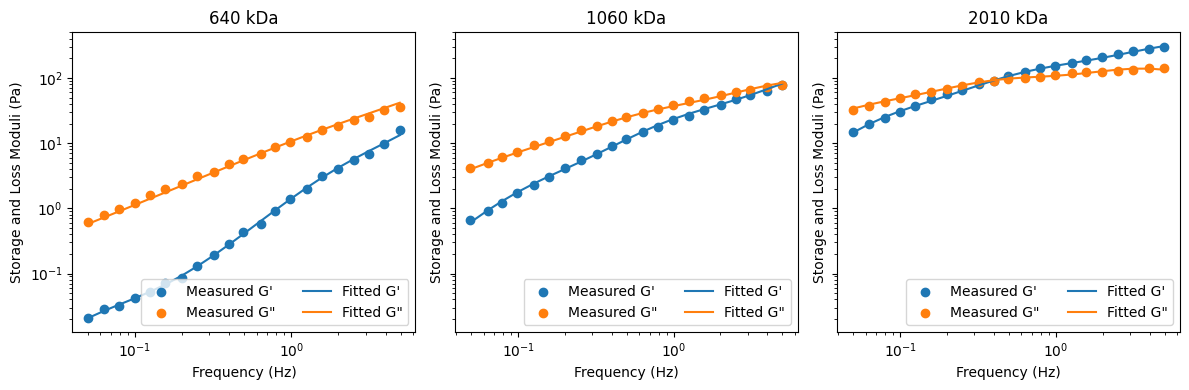

In [132]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

plot_saos(ax[0], saos640, '640 kDa')
plot_saos(ax[1], saos1060, '1060 kDa')
plot_saos(ax[2], saos2010, '2010 kDa')

fig.tight_layout()
fig.savefig('saos.svg')

In [180]:
def viscosity(gamma_dot, fit, *params):
    """
    Cumulative viscosity function for linear PTT model

    Parameters
    ----------
        gamma_dot : shear rate
        L: list of relaxation times
        *params : list of epsilon [epsilon_i ... epsilon_n]
    
    """
    L_list = fit[1::2]
    eta0_mode = fit[::2] * fit[1::2]
    epsilon_mode = params

    eta = np.zeros_like(gamma_dot)

    for L_i, eta0_i, epsilon_i in zip(L_list, eta0_mode, epsilon_mode):

        denom = (1 + (2*epsilon_i * ((L_i * gamma_dot)**2))) ** (1/3)
        eta += eta0_i / denom

    return eta

In [181]:
def steady_fit(data, saos_popt):
    fit_func = lambda gamma_dot, *params: viscosity(gamma_dot, saos_popt, *params)

    initial = [0.1, 0.1, 0.1]

    popt, _ = curve_fit(fit_func, data['Shear rate'], data['Viscosity'], bounds=(0, np.inf), p0=initial, sigma=data['Viscosity'])
    data['Fit'] = viscosity(data['Shear rate'], saos_popt, *popt)
    return popt

In [182]:
steadyfit_640 = steady_fit(steady640, saosfit_640)
steadyfit_1060 = steady_fit(steady1060, saosfit_1060)
steadyfit_2010 = steady_fit(steady2010, saosfit_2010)

In [183]:
def plot_steady(data, ax):
    ax.scatter(data['Shear rate'], data['Viscosity'])
    ax.plot(data['Shear rate'], data['Fit'])

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel('Shear rate (Hz)')
    ax.set_ylabel('Viscosity (Pa * s)')

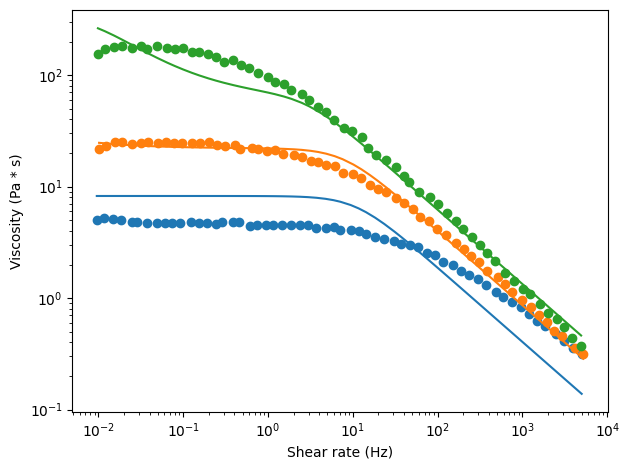

In [184]:
fig, ax = plt.subplots(1, 1)

plot_steady(steady640, ax)
plot_steady(steady1060, ax)
plot_steady(steady2010, ax)

fig.tight_layout()

In [ ]:
steadyfit_1060

array([1.09544902e+02, 5.69314815e-02, 4.88525353e+01, 3.64027921e-02,
       1.68940393e+01, 2.80015772e+00])